<a href="https://colab.research.google.com/github/Giraffe-Shin/trading/blob/main/Basic/Basic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from google.colab import userdata

# 기존 설정 재사용
try:
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main' # 이 부분은 contents API에서는 직접적으로 사용되지 않지만, 다른 작업 시 필요할 수 있습니다.
directory_path = 'data'

# GitHub API를 사용하여 디렉토리 내용 가져오기
api_url = f'https://api.github.com/repos/{username}/{repo}/contents/{directory_path}'

headers = {
    'Authorization': f'token {github_token}',
    'Accept': 'application/vnd.github.v3+json' # GitHub API 버전 3 사용 명시
}

try:
    response = requests.get(api_url, headers=headers)

    if response.status_code == 200:
        contents = response.json()
        file_names = [item['name'] for item in contents if item['type'] == 'file']
        print(f"'{directory_path}' 디렉토리의 파일 목록:")
        for file_name in file_names:
            print(f"- {file_name}")
    elif response.status_code == 401:
        print("인증 실패: 토큰이 유효하지 않거나 권한이 없습니다. GitHub 토큰을 확인해주세요.")
    elif response.status_code == 404:
        print(f"디렉토리 '{directory_path}'를 찾을 수 없습니다. 경로를 확인해주세요.")
    else:
        print(f"파일 목록을 가져오는 데 실패했습니다. 상태 코드: {response.status_code}, 메시지: {response.text}")
except Exception as e:
    print(f"오류 발생: {e}")


'data' 디렉토리의 파일 목록:
- germany_actual_generation.csv
- germany_cbet_trading.csv
- germany_cbpf_physical_flow.csv
- germany_energy_master.csv
- germany_forecast_day_ahead.csv
- germany_market_prices.csv
- germany_renewable_share_daily.csv


ㅔ

In [ ]:
import pandas as pd
import requests
from io import StringIO
from google.colab import userdata

# --- 필수 설정 ---
try:
    # Colab 보안 비밀(Secrets)에서 토큰을 가져옵니다.
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main'
file_path = 'data/germany_actual_generation.csv'

# API를 통한 프라이빗 파일 접근 URL
url = f'https://raw.githubusercontent.com/{username}/{repo}/{branch}/{file_path}'

headers = {'Authorization': f'token {github_token}'}

try:
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        df = pd.read_csv(StringIO(response.text))
        print("성공적으로 파일을 불러왔습니다!")
        display(df.head())
    elif response.status_code == 401:
        print("인증 실패: 토큰이 유효하지 않거나 권한이 없습니다.")
    elif response.status_code == 404:
        print("파일을 찾을 수 없습니다(404). 토큰 이름, 경로, 브랜치명을 다시 확인해주세요.")
    else:
        print(f"실패했습니다. 상태 코드: {response.status_code}")
except Exception as e:
    print(f"오류 발생: {e}")

성공적으로 파일을 불러왔습니다!


,timestamp,Hydro pumped storage consumption,Cross border electricity trading,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,...,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Load,Residual load,Renewable share of load,Renewable share of generation
0,2022-12-31 23:00:00,-1975.8,-12645.2,2460.7,1627.7,4022.8,3845.6,1825.5,306.0,670.0,...,127.0,187.4,1050.3,2739.0,27260.9,0.0,38691.8,8691.8,93.7,75.5
1,2022-12-31 23:15:00,-2009.5,-12544.0,2458.5,1624.8,4012.0,3847.7,1828.6,306.8,648.2,...,180.1,187.3,1049.1,2975.6,27311.5,0.0,38374.2,8087.1,95.1,75.7
2,2022-12-31 23:30:00,-2244.0,-12526.2,2459.6,1624.8,4010.0,3860.2,1825.2,306.9,648.2,...,106.9,187.2,1055.2,3269.6,27699.4,0.0,38248.0,7279.0,97.2,76.0
3,2022-12-31 23:45:00,-2077.3,-12515.4,2457.9,1622.0,4004.0,3861.6,1819.7,306.0,639.1,...,87.0,187.3,1043.6,3259.5,27170.0,0.0,38070.2,7640.6,96.3,75.8
4,2023-01-01 00:00:00,-1204.1,-15410.1,2457.7,1622.3,3988.4,3869.8,1811.4,306.0,635.0,...,547.7,187.3,1047.1,3144.1,27853.6,0.0,37733.4,6735.7,98.5,76.3


In [ ]:
# 데이터프레임의 컬럼 이름 리스트 출력
column_list = df.columns.tolist()
print(column_list)

['timestamp', 'Hydro pumped storage consumption', 'Cross border electricity trading', 'Nuclear', 'Hydro Run-of-River', 'Biomass', 'Fossil brown coal / lignite', 'Fossil hard coal', 'Fossil oil', 'Fossil coal-derived gas', 'Fossil gas', 'Geothermal', 'Hydro water reservoir', 'Hydro pumped storage', 'Others', 'Waste', 'Wind offshore', 'Wind onshore', 'Solar', 'Load', 'Residual load', 'Renewable share of load', 'Renewable share of generation']


In [ ]:
# 제외할 컬럼 리스트
cols_to_exclude = [
    "Load",
    "Residual load",
    "Renewable share of generation",
    "Renewable share of load",
    "Cross border electricity trading"
]

# 해당 컬럼들을 제외하고 데이터프레임 업데이트
df = df.drop(columns=cols_to_exclude)

# 결과 확인
print("남은 컬럼 목록:")
print(df.columns.tolist())
display(df.head())

남은 컬럼 목록:
['timestamp', 'Hydro pumped storage consumption', 'Nuclear', 'Hydro Run-of-River', 'Biomass', 'Fossil brown coal / lignite', 'Fossil hard coal', 'Fossil oil', 'Fossil coal-derived gas', 'Fossil gas', 'Geothermal', 'Hydro water reservoir', 'Hydro pumped storage', 'Others', 'Waste', 'Wind offshore', 'Wind onshore', 'Solar']


,timestamp,Hydro pumped storage consumption,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar
0,2022-12-31 23:00:00,-1975.8,2460.7,1627.7,4022.8,3845.6,1825.5,306.0,670.0,1882.0,18.2,73.1,127.0,187.4,1050.3,2739.0,27260.9,0.0
1,2022-12-31 23:15:00,-2009.5,2458.5,1624.8,4012.0,3847.7,1828.6,306.8,648.2,1880.9,18.5,65.9,180.1,187.3,1049.1,2975.6,27311.5,0.0
2,2022-12-31 23:30:00,-2244.0,2459.6,1624.8,4010.0,3860.2,1825.2,306.9,648.2,1893.2,18.7,65.4,106.9,187.2,1055.2,3269.6,27699.4,0.0
3,2022-12-31 23:45:00,-2077.3,2457.9,1622.0,4004.0,3861.6,1819.7,306.0,639.1,1885.9,18.6,83.6,87.0,187.3,1043.6,3259.5,27170.0,0.0
4,2023-01-01 00:00:00,-1204.1,2457.7,1622.3,3988.4,3869.8,1811.4,306.0,635.0,1696.4,18.6,57.3,547.7,187.3,1047.1,3144.1,27853.6,0.0


In [ ]:
# 'timestamp'를 제외한 모든 수치형 열의 합계를 구하여 새로운 'Total' 열 생성
numeric_cols = df.columns.drop('timestamp')
df['Total'] = df[numeric_cols].sum(axis=1)

# 결과 확인
display(df[['timestamp'] + list(numeric_cols) + ['Total']].head())

,timestamp,Hydro pumped storage consumption,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Total
0,2022-12-31 23:00:00,-1975.8,2460.7,1627.7,4022.8,3845.6,1825.5,306.0,670.0,1882.0,18.2,73.1,127.0,187.4,1050.3,2739.0,27260.9,0.0,46120.4
1,2022-12-31 23:15:00,-2009.5,2458.5,1624.8,4012.0,3847.7,1828.6,306.8,648.2,1880.9,18.5,65.9,180.1,187.3,1049.1,2975.6,27311.5,0.0,46386.0
2,2022-12-31 23:30:00,-2244.0,2459.6,1624.8,4010.0,3860.2,1825.2,306.9,648.2,1893.2,18.7,65.4,106.9,187.2,1055.2,3269.6,27699.4,0.0,46786.5
3,2022-12-31 23:45:00,-2077.3,2457.9,1622.0,4004.0,3861.6,1819.7,306.0,639.1,1885.9,18.6,83.6,87.0,187.3,1043.6,3259.5,27170.0,0.0,46368.5
4,2023-01-01 00:00:00,-1204.1,2457.7,1622.3,3988.4,3869.8,1811.4,306.0,635.0,1696.4,18.6,57.3,547.7,187.3,1047.1,3144.1,27853.6,0.0,48038.6


In [ ]:
# timestamp 컬럼을 datetime 형식으로 변환
df['timestamp'] = pd.to_datetime(df['timestamp'])

# timestamp를 인덱스로 설정
df.set_index('timestamp', inplace=True)

# 일간 발전량 합계 계산 (Resampling)
df_daily = df.resample('D').sum()

# 결과 확인
display(df_daily.head())

,Hydro pumped storage consumption,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Total
timestamp,,,,,,,,,,,,,,,,,,
2022-12-31,-8306.6,9836.7,6499.3,16048.8,15415.1,7299.0,1225.7,2605.5,7542.0,74.0,288.0,501.0,749.2,4198.2,12243.7,109441.8,0.0,185661.4
2023-01-01,-176838.7,236156.5,153039.1,400955.1,393866.1,175842.3,29458.2,57923.7,167836.7,1699.4,5459.7,74270.5,18004.2,99680.8,435537.5,2102568.6,172780.1,4348239.8
2023-01-02,-136008.9,236123.5,153939.3,416559.2,1056996.6,276313.9,29376.0,55709.4,254511.8,1706.1,5769.5,105649.4,21255.9,103976.8,348172.4,2199020.0,132826.1,5261897.0
2023-01-03,-118309.8,236221.2,163420.2,424843.7,1236960.9,565152.4,28825.6,51018.0,364478.7,1804.6,7644.7,183770.6,26124.1,98196.1,410475.3,1278691.4,179359.7,5138677.4
2023-01-04,-255975.4,233569.0,160657.5,421491.9,482798.0,447796.0,28578.4,42980.8,246745.8,1709.5,6086.8,97290.9,18564.8,72846.5,495433.1,3675321.4,52525.2,6228420.2


In [ ]:
# 15분 간격 데이터를 MWh로 변환 (MW * 15/60)
df['total_MWh'] = df['Total'] * (15/60)

# 일간 MWh 합계 계산
df_daily_mwh = df['total_MWh'].resample('D').sum()

# 결과 확인 (최근 5일)
print("일간 발전량 합계 (MWh):")
print(df_daily_mwh.tail())

# 전체 평균 하루 발전량 확인
avg_daily_mwh = df_daily_mwh.mean()
print(f"\n평균 일간 발전량: {avg_daily_mwh:,.0f} MWh")

일간 발전량 합계 (MWh):
timestamp
2026-06-06     893345.075
2026-06-07    1003909.950
2026-06-08    1103853.375
2026-06-09    1213737.350
2026-06-10     626367.325
Freq: D, Name: total_MWh, dtype: float64

평균 일간 발전량: 1,152,723 MWh


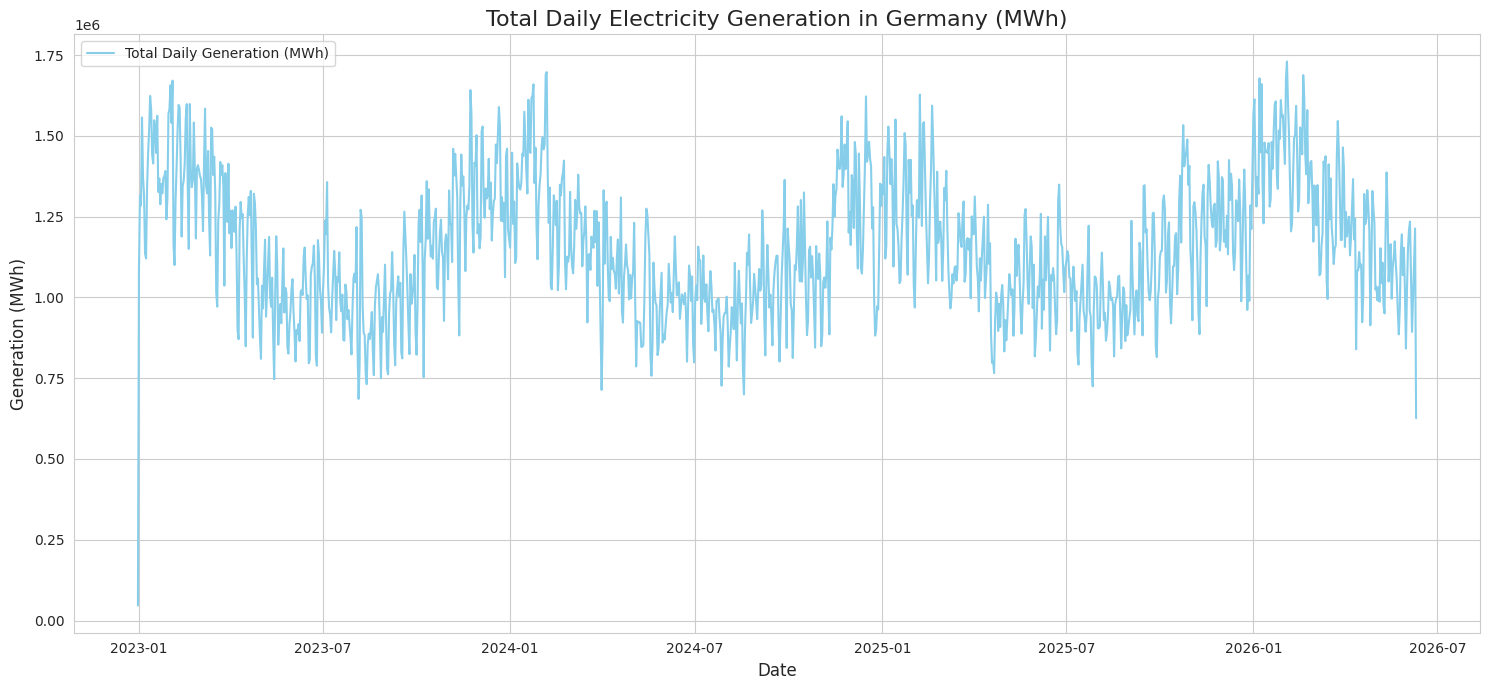


Insight 1: The plot above shows the trend of total daily electricity generation over time. We can observe seasonal patterns and overall changes in generation levels.


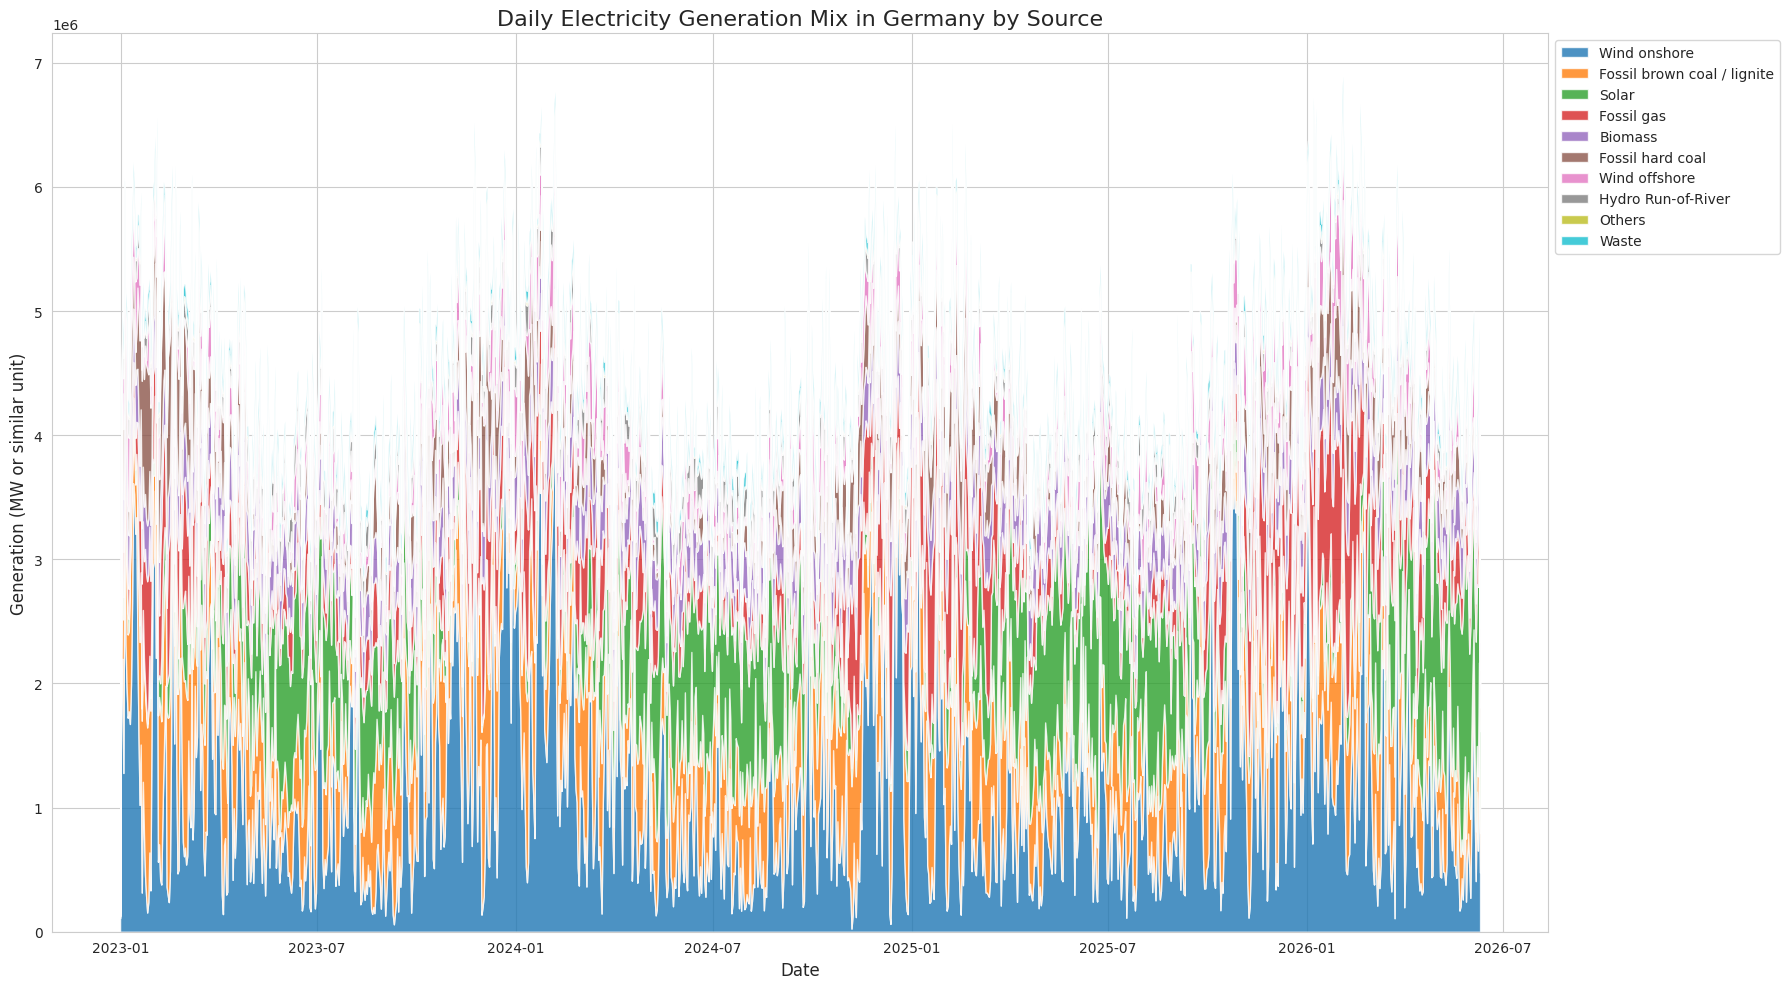


Insight 2: The stacked area chart illustrates the contribution of different energy sources to the total daily generation. This helps in understanding the energy mix, the dominance of certain sources (e.g., Fossil fuels, Wind, Solar), and how the reliance on these sources changes over time, potentially reflecting policy changes or seasonal availability (e.g., higher wind/solar in certain periods).
Insight 3: By observing the 'Fossil brown coal / lignite' and 'Fossil hard coal' trends, we can gauge the reliance on fossil fuels. Similarly, 'Wind offshore', 'Wind onshore', and 'Solar' show the growth and variability of renewable energy sources. Changes in 'Nuclear' generation might indicate plant shutdowns or operational changes.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# 1. Total Daily Electricity Generation (MWh)
plt.figure(figsize=(15, 7))
plt.plot(df_daily_mwh.index, df_daily_mwh.values, label='Total Daily Generation (MWh)', color='skyblue')
plt.title('Total Daily Electricity Generation in Germany (MWh)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Generation (MWh)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInsight 1: The plot above shows the trend of total daily electricity generation over time. We can observe seasonal patterns and overall changes in generation levels.")

# 2. Daily Generation Mix (Stacked Area Plot)
# Exclude 'Total' column if it exists in df_daily after resampling
if 'Total' in df_daily.columns:
    df_daily_plot = df_daily.drop(columns=['Total'])
else:
    df_daily_plot = df_daily.copy()

# Select top N sources for clarity, or plot all if manageable
# For this example, let's take some key sources and 'Others'
# Sorting by mean generation to get prominent sources
sources_mean = df_daily_plot.mean().sort_values(ascending=False)

# Let's consider the top 8 sources plus 'Others' and 'Waste' if not in top 8
top_sources = sources_mean.head(8).index.tolist()

# Ensure 'Others' and 'Waste' are included if they are present in the dataframe
if 'Others' in df_daily_plot.columns and 'Others' not in top_sources:
    top_sources.append('Others')
if 'Waste' in df_daily_plot.columns and 'Waste' not in top_sources:
    top_sources.append('Waste')

# Filter df_daily_plot to include only the selected sources
df_daily_mix = df_daily_plot[top_sources]

plt.figure(figsize=(18, 10))
# Convert to MWh for better comparison if needed, or keep in original units
# Assuming original units are already comparable or MWh transformation is done globally
plt.stackplot(df_daily_mix.index, df_daily_mix.values.T, labels=df_daily_mix.columns,
              alpha=0.8)
plt.title('Daily Electricity Generation Mix in Germany by Source', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Generation (MW or similar unit)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInsight 2: The stacked area chart illustrates the contribution of different energy sources to the total daily generation. This helps in understanding the energy mix, the dominance of certain sources (e.g., Fossil fuels, Wind, Solar), and how the reliance on these sources changes over time, potentially reflecting policy changes or seasonal availability (e.g., higher wind/solar in certain periods).")

print("Insight 3: By observing the 'Fossil brown coal / lignite' and 'Fossil hard coal' trends, we can gauge the reliance on fossil fuels. Similarly, 'Wind offshore', 'Wind onshore', and 'Solar' show the growth and variability of renewable energy sources. Changes in 'Nuclear' generation might indicate plant shutdowns or operational changes.")

In [ ]:
import pandas as pd

# Ensure df_daily exists by using the existing 'df' in memory
# Based on previous cells, 'df' has 'timestamp' as index or column
if 'df' in globals():
    # If 'timestamp' is already the index, use it; otherwise set it
    if df.index.name == 'timestamp':
        df_daily = df.resample('D').sum()
    elif 'timestamp' in df.columns:
        df_daily = df.set_index('timestamp').resample('D').sum()
    else:
        # Fallback if index/column state is ambiguous
        df_daily = df.resample('D').sum()

# 1. 태양광(Solar), 풍력(Wind Onshore/Offshore) 비중 계산
# 제외할 비수치/중복 컬럼들
exclude = ['Total', 'total_MWh', 'Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share', 'Renewable_Total_Share']
numeric_cols = [col for col in df_daily.columns if col not in exclude]

# 전체 발전량 재계산 (정확한 분모 설정을 위해)
df_daily['Total_Calc'] = df_daily[numeric_cols].sum(axis=1)

# 비중 계산
df_daily['Solar_Share'] = df_daily['Solar'] / df_daily['Total_Calc']
df_daily['Wind_Onshore_Share'] = df_daily['Wind onshore'] / df_daily['Total_Calc']
df_daily['Wind_Offshore_Share'] = df_daily['Wind offshore'] / df_daily['Total_Calc']

# 2. 신재생 에너지 전체 비율 계산
renewable_cols = [
    'Hydro Run-of-River', 'Biomass', 'Geothermal',
    'Hydro water reservoir', 'Wind offshore', 'Wind onshore', 'Solar'
]

available_renewables = [col for col in renewable_cols if col in df_daily.columns]
df_daily['Renewable_Total_Share'] = df_daily[available_renewables].sum(axis=1) / df_daily['Total_Calc']

# 결과 확인
display_cols = ['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share', 'Renewable_Total_Share']
display(df_daily[display_cols].head())

print("\n[통계 요약]")
display(df_daily[display_cols].describe())

,Solar_Share,Wind_Onshore_Share,Wind_Offshore_Share,Renewable_Total_Share
timestamp,,,,
2022-12-31,0.000000,0.589470,0.065946,0.778813
2023-01-01,0.039736,0.483545,0.100164,0.752497
2023-01-02,0.025243,0.417914,0.066169,0.619167
2023-01-03,0.034904,0.248837,0.079880,0.479937
2023-01-04,0.008433,0.590089,0.079544,0.772784



[통계 요약]


,Solar_Share,Wind_Onshore_Share,Wind_Offshore_Share,Renewable_Total_Share
count,1258.000000,1258.000000,1258.000000,1258.000000
mean,0.164812,0.248814,0.059445,0.609767
std,0.118318,0.143944,0.030755,0.149473
min,0.000000,0.006160,0.000161,0.196660
25%,0.052493,0.129782,0.034288,0.515786
50%,0.150179,0.225844,0.059054,0.624046
75%,0.256662,0.343699,0.082414,0.728577
max,0.496249,0.656520,0.142660,0.906694


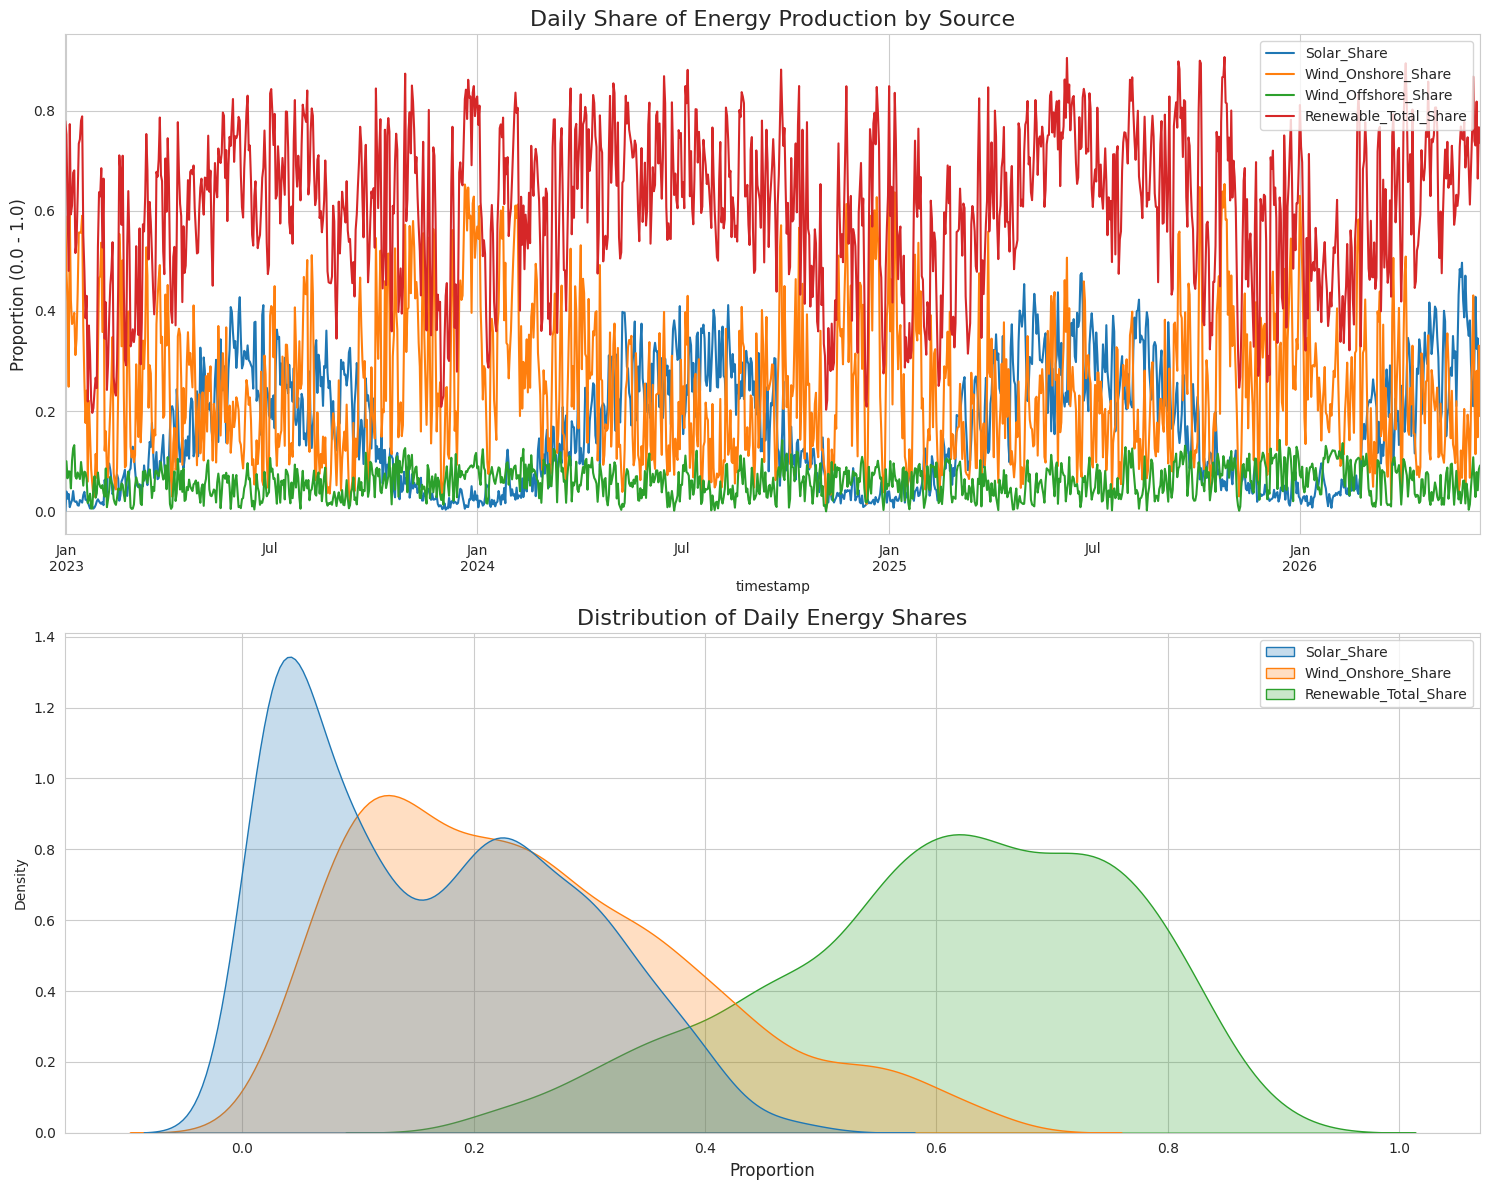

### [Key Insights from Energy Share Analysis] ###
1. 평균 신재생 에너지 비중: 전체 발전량 중 신재생 에너지가 차지하는 평균 비중은 약 61.0%로, 에너지 전환이 상당히 진행되었음을 보여줍니다.
2. 풍력 vs 태양광: 풍력(Onshore+Offshore)의 평균 비중(30.8%)이 태양광(16.5%)보다 높게 나타나며, 독일 에너지 생산의 핵심적인 역할을 하고 있습니다.
3. 변동성 리스크: 신재생 에너지 비중의 표준편차가 0.15로 나타나며, 기상 조건에 따라 하루 발전 비중이 급격히 변동하는 '간헐성' 문제가 시각적으로 확인됩니다.
4. 최대 공급 능력: 특정 일자에는 신재생 에너지 비중이 최대 90.7%까지 상승하며, 화석 연료 없이도 국가 전력 수요의 상당 부분을 충당할 수 있는 잠재력을 보여줍니다.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Trend of Energy Shares over Time
df_daily[['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share', 'Renewable_Total_Share']].plot(ax=axes[0], linewidth=1.5)
axes[0].set_title('Daily Share of Energy Production by Source', fontsize=16)
axes[0].set_ylabel('Proportion (0.0 - 1.0)', fontsize=12)
axes[0].legend(loc='upper right')

# 2. Distribution of Renewable Shares
sns.kdeplot(data=df_daily[['Solar_Share', 'Wind_Onshore_Share', 'Renewable_Total_Share']], fill=True, ax=axes[1])
axes[1].set_title('Distribution of Daily Energy Shares', fontsize=16)
axes[1].set_xlabel('Proportion', fontsize=12)

plt.tight_layout()
plt.show()

# --- Insight Extraction ---
print("### [Key Insights from Energy Share Analysis] ###")

# 1. Renewable Dominance
avg_renewable = df_daily['Renewable_Total_Share'].mean() * 100
print(f"1. 평균 신재생 에너지 비중: 전체 발전량 중 신재생 에너지가 차지하는 평균 비중은 약 {avg_renewable:.1f}%로, 에너지 전환이 상당히 진행되었음을 보여줍니다.")

# 2. Wind vs Solar
wind_total_avg = (df_daily['Wind_Onshore_Share'].mean() + df_daily['Wind_Offshore_Share'].mean()) * 100
solar_avg = df_daily['Solar_Share'].mean() * 100
print(f"2. 풍력 vs 태양광: 풍력(Onshore+Offshore)의 평균 비중({wind_total_avg:.1f}%)이 태양광({solar_avg:.1f}%)보다 높게 나타나며, 독일 에너지 생산의 핵심적인 역할을 하고 있습니다.")

# 3. Variability & Volatility
renewable_std = df_daily['Renewable_Total_Share'].std()
print(f"3. 변동성 리스크: 신재생 에너지 비중의 표준편차가 {renewable_std:.2f}로 나타나며, 기상 조건에 따라 하루 발전 비중이 급격히 변동하는 '간헐성' 문제가 시각적으로 확인됩니다.")

# 4. Seasonal/Daily Peaks
max_renewable = df_daily['Renewable_Total_Share'].max() * 100
print(f"4. 최대 공급 능력: 특정 일자에는 신재생 에너지 비중이 최대 {max_renewable:.1f}%까지 상승하며, 화석 연료 없이도 국가 전력 수요의 상당 부분을 충당할 수 있는 잠재력을 보여줍니다.")